# Basic Exploratory Data Analysis (EDA)



In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# Load dataset
df = pd.read_excel("Master Data.xlsx")

print("Dataset loaded successfully!")
display(df.head())

Dataset loaded successfully!


,Date,UWG_Mailing,BFCM_Promo_Effect,holiday_list,Offline_Promo,Promotion_Discount,Total_Revenue,Revenue_New_Customer,influencer_spend,Awin_spend,microsoft_spend,criteo_spend,cost_outbrain,spend_Google_Branded,spend_Google_Non_Branded,spend_Google_PMAX,spend_Google_Demand_Gen,spend_Google_Others,spend_Meta_ASC,spend_Meta_Retargeting,spend_Meta_Prospecting,spend_Google,spend_Meta
0,2024-04-01,0,0,1,1,1,106943.0,38956.59,0.0,582.67,104.84,235.109051,93.0,1397.096871,248.70,1236.751429,41.532079,56.85,622.880000,289.149999,312.860001,2980.930379,1224.890000
1,2024-04-02,0,0,0,1,1,97629.0,34755.77,0.0,488.37,114.55,213.882456,95.0,1156.952320,239.56,1201.819981,42.691111,37.41,608.129999,281.100000,304.180000,2678.433412,1193.409999
2,2024-04-03,0,0,0,1,1,86273.0,33922.82,0.0,525.69,126.22,149.522513,94.0,1305.355626,245.65,1081.493097,43.278069,34.15,604.330001,278.690000,301.830000,2709.926792,1184.850001
3,2024-04-04,0,0,0,1,1,98247.0,35323.97,0.0,531.80,101.88,145.081980,94.0,1289.010803,300.35,1547.723387,41.585903,27.95,596.169998,276.640000,298.620000,3206.620093,1171.429998
4,2024-04-05,0,0,0,1,1,83678.0,29061.76,0.0,500.02,108.41,128.825199,93.0,1239.129205,344.52,1524.926574,44.156125,23.39,597.270000,277.800001,298.530001,3176.121904,1173.600002


## 1. Basic Information



In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

Number of rows: 852
Number of columns: 23

Column names:
['Date', 'UWG_Mailing', 'BFCM_Promo_Effect', 'holiday_list', 'Offline_Promo', 'Promotion_Discount', 'Total_Revenue', 'Revenue_New_Customer', 'influencer_spend', 'Awin_spend', 'microsoft_spend', 'criteo_spend', 'cost_outbrain', 'spend_Google_Branded', 'spend_Google_Non_Branded', 'spend_Google_PMAX', 'spend_Google_Demand_Gen', 'spend_Google_Others', 'spend_Meta_ASC', 'spend_Meta_Retargeting', 'spend_Meta_Prospecting', 'spend_Google', 'spend_Meta']

Data types:


,Data Type
Date,datetime64[ns]
UWG_Mailing,int64
BFCM_Promo_Effect,int64
holiday_list,int64
Offline_Promo,int64
Promotion_Discount,int64
Total_Revenue,float64
Revenue_New_Customer,float64
influencer_spend,float64
Awin_spend,float64


## 2. Missing Values



In [3]:
missing = df.isnull().sum()

print("Missing values in each column:")
display(missing.to_frame("Missing Values"))

print("Total missing values:", missing.sum())

Missing values in each column:


,Missing Values
Date,0
UWG_Mailing,0
BFCM_Promo_Effect,0
holiday_list,0
Offline_Promo,0
Promotion_Discount,0
Total_Revenue,0
Revenue_New_Customer,0
influencer_spend,0
Awin_spend,0


Total missing values: 0


## 3. Duplicate Records


In [4]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


## 4. Handling Missing Values



In [5]:
# Fill missing numerical values with median
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with mode
categorical_columns = df.select_dtypes(exclude=np.number).columns

for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()
        if len(mode_value) > 0:
            df[col] = df[col].fillna(mode_value[0])

print("Remaining missing values:")
display(df.isnull().sum().to_frame("Missing Values"))

Remaining missing values:


,Missing Values
Date,0
UWG_Mailing,0
BFCM_Promo_Effect,0
holiday_list,0
Offline_Promo,0
Promotion_Discount,0
Total_Revenue,0
Revenue_New_Customer,0
influencer_spend,0
Awin_spend,0


## 5. Descriptive Statistics



In [6]:
numeric_columns = df.select_dtypes(include=np.number).columns

if len(numeric_columns) > 0:
    display(df[numeric_columns].describe().T)
else:
    print("No numerical columns found.")

,count,mean,std,min,25%,50%,75%,max
UWG_Mailing,852.0,0.089202,0.285202,0.00,0.000000,0.000000,0.000000,1.000000
BFCM_Promo_Effect,852.0,0.019953,0.139921,0.00,0.000000,0.000000,0.000000,1.000000
holiday_list,852.0,0.046948,0.211653,0.00,0.000000,0.000000,0.000000,1.000000
Offline_Promo,852.0,0.178404,0.383077,0.00,0.000000,0.000000,0.000000,1.000000
Promotion_Discount,852.0,0.671362,0.469994,0.00,0.000000,1.000000,1.000000,1.000000
Total_Revenue,852.0,62091.129977,32998.694646,11848.00,43792.882500,54426.500000,69063.250000,289548.000000
Revenue_New_Customer,852.0,20163.691270,8408.148343,1407.55,15185.597500,18923.400000,23693.780000,86734.110000
influencer_spend,852.0,46.670575,370.172827,0.00,0.000000,0.000000,0.000000,5333.333333
Awin_spend,852.0,287.279802,198.985905,34.88,155.600000,240.220000,352.159550,1642.120000
microsoft_spend,852.0,118.840986,35.844594,7.14,95.535000,116.225000,141.627500,313.380000


## 6. Categorical Summary



In [7]:
categorical_columns = df.select_dtypes(exclude=np.number).columns

for col in categorical_columns:
    print("\nColumn:", col)
    print("Number of unique values:", df[col].nunique())
    display(df[col].value_counts().head(10).to_frame("Count"))


Column: Date
Number of unique values: 852


,Count
Date,
2026-07-31,1
2024-04-01,1
2024-04-02,1
2024-04-03,1
2026-07-15,1
2026-07-14,1
2026-07-13,1
2026-07-12,1
2026-07-11,1


## 7. Histograms



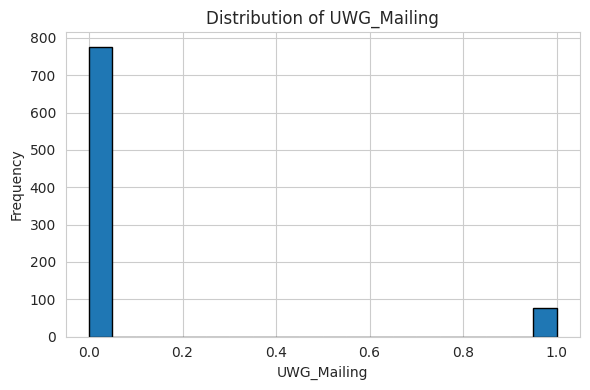

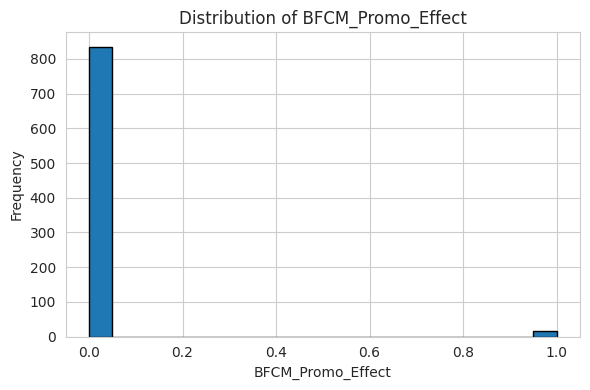

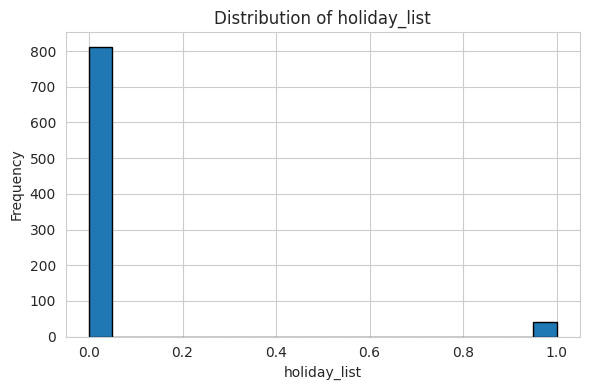

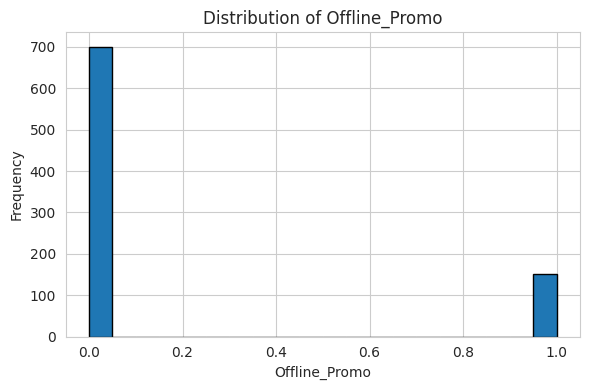

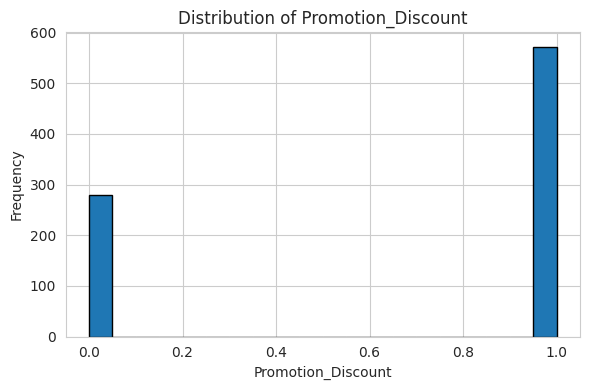

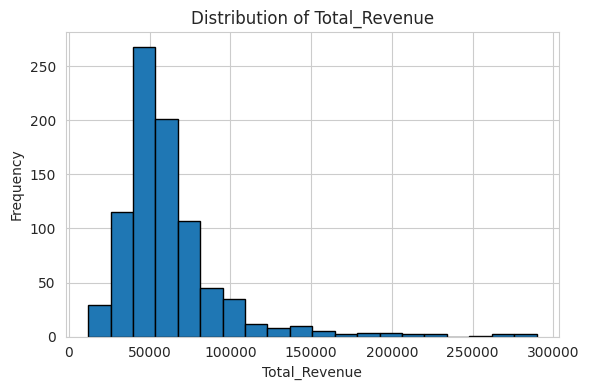

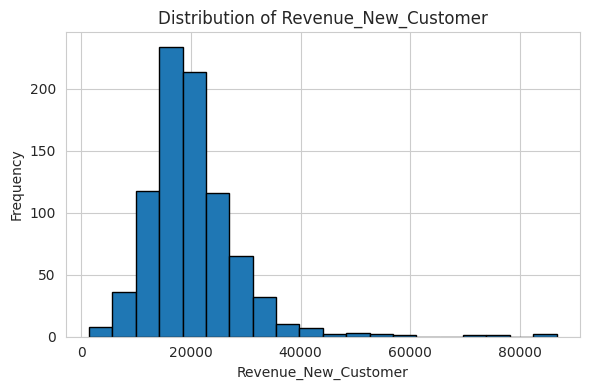

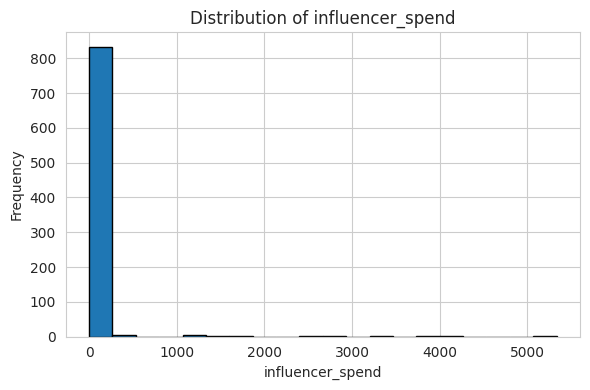

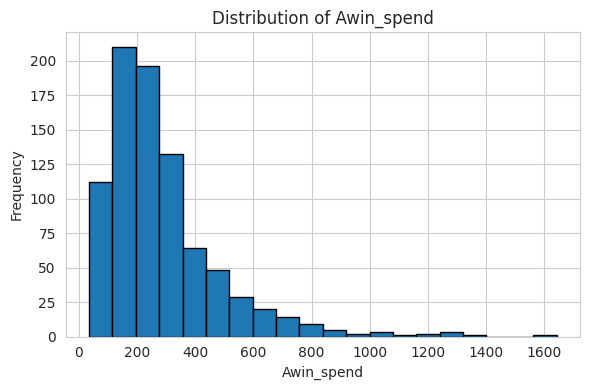

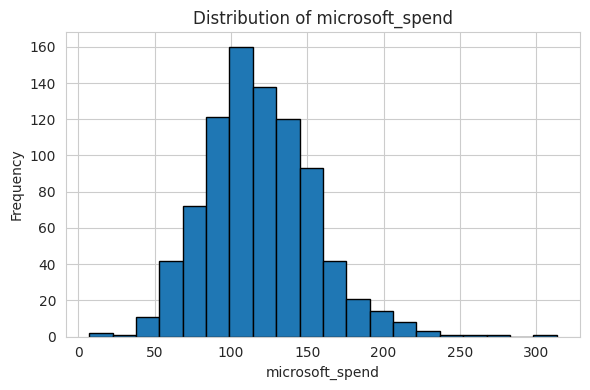

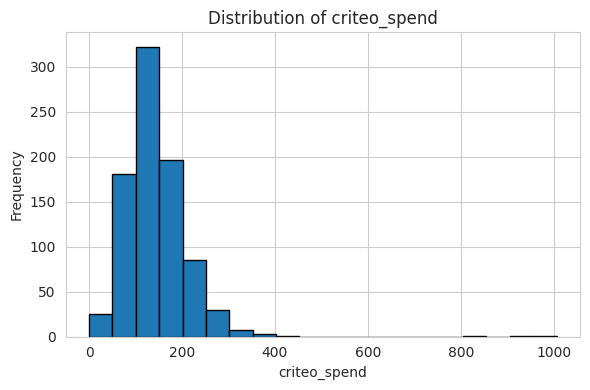

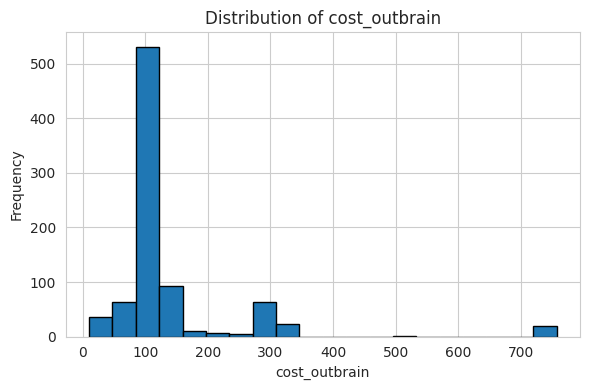

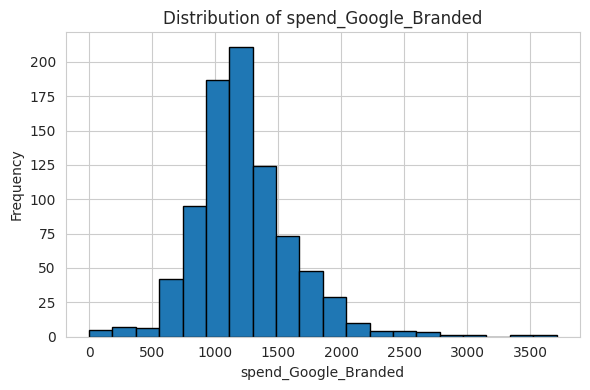

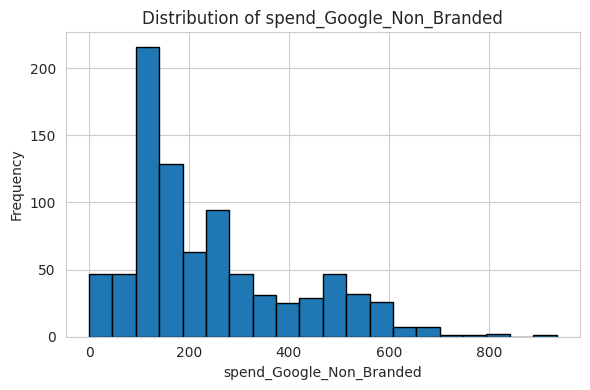

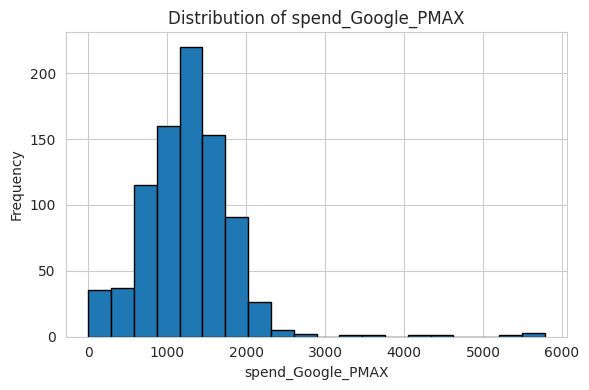

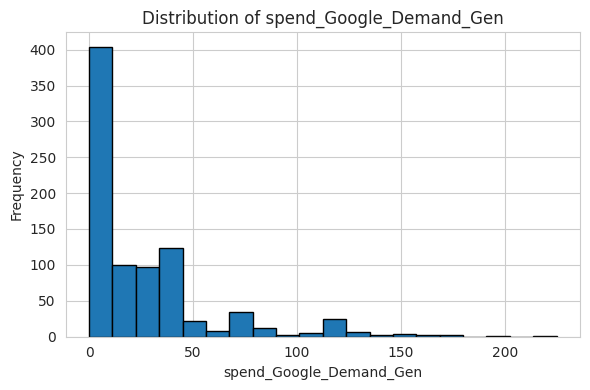

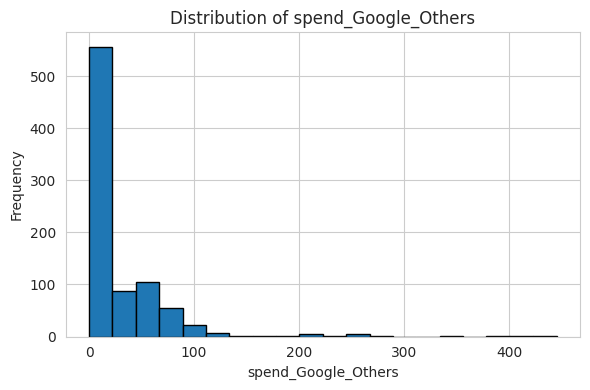

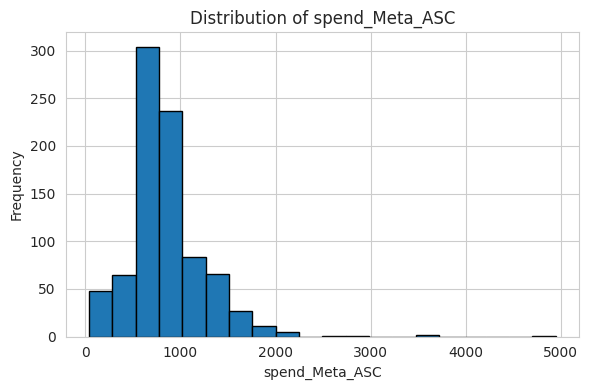

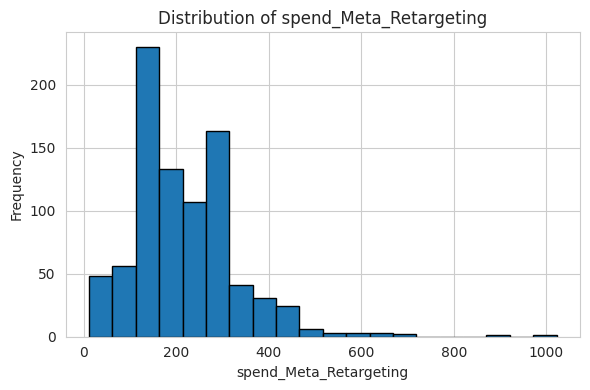

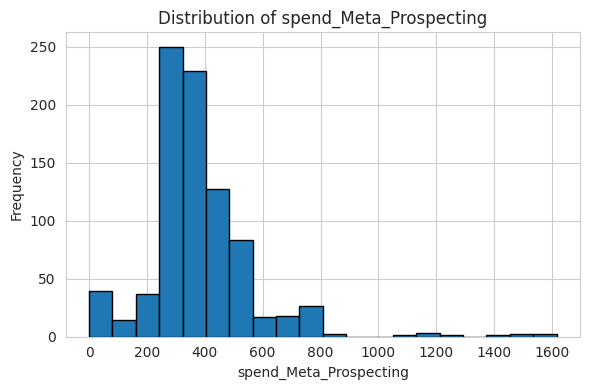

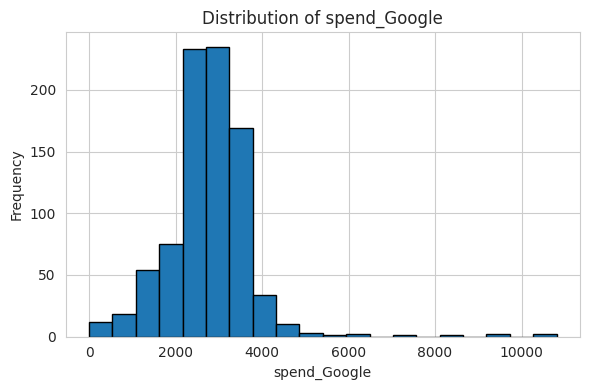

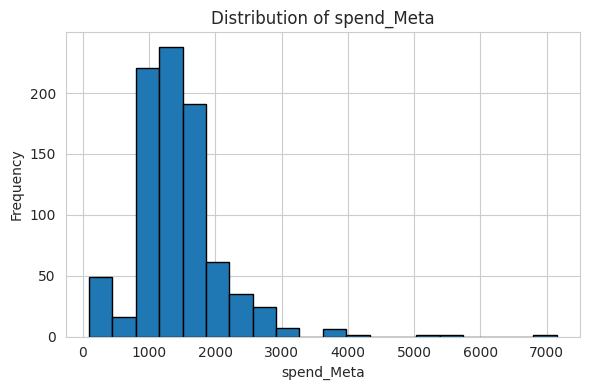

In [8]:
# Simple histograms
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=20, edgecolor="black")
    plt.title("Distribution of " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 8. Boxplots



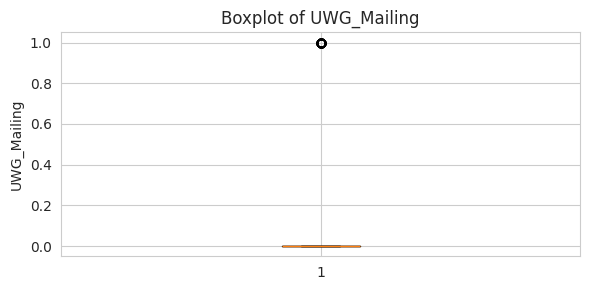

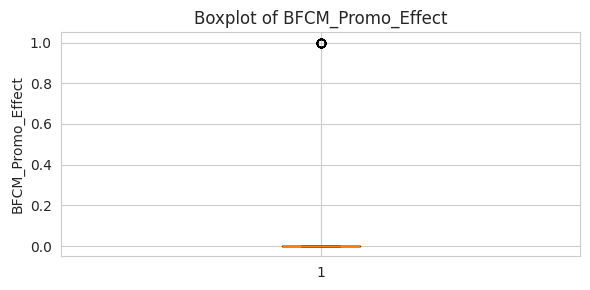

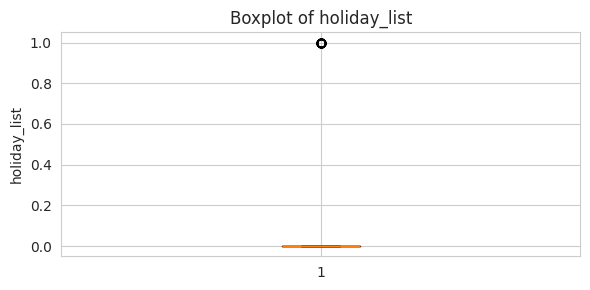

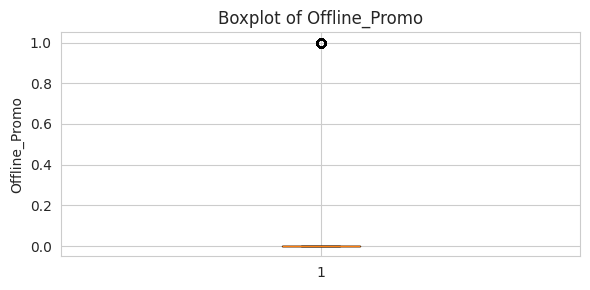

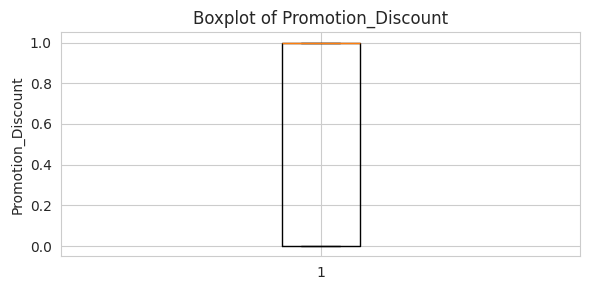

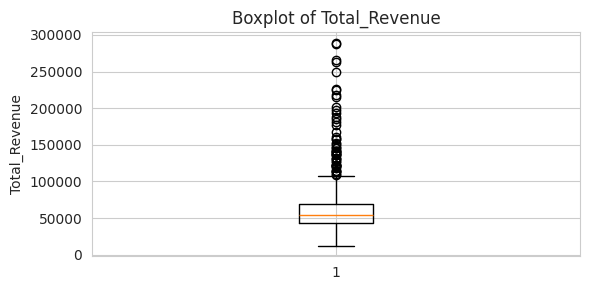

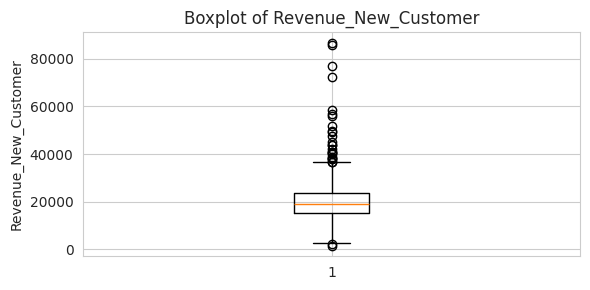

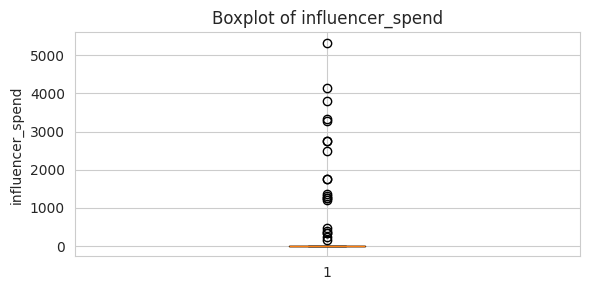

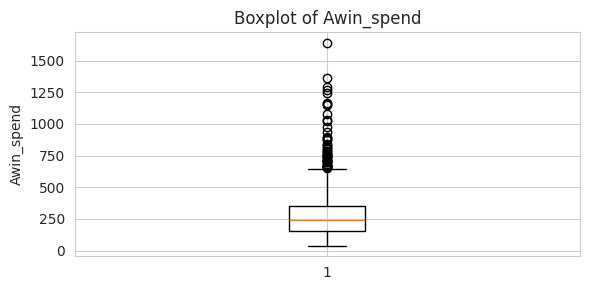

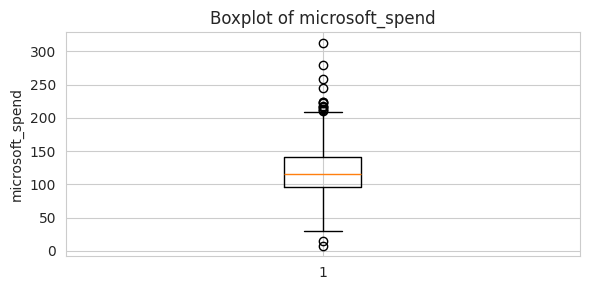

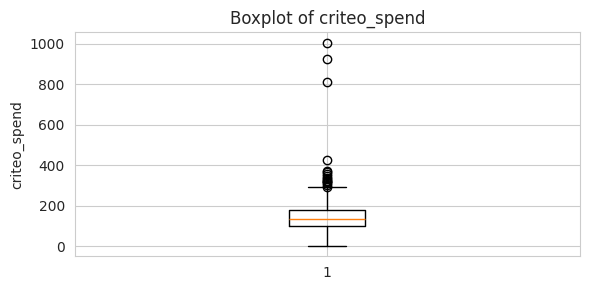

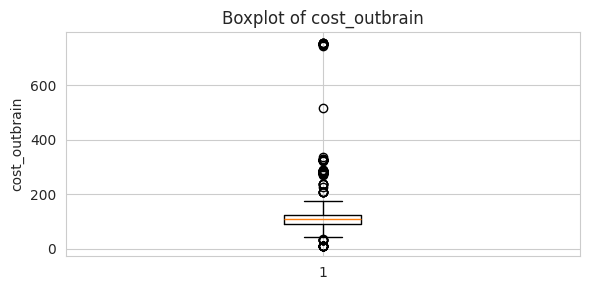

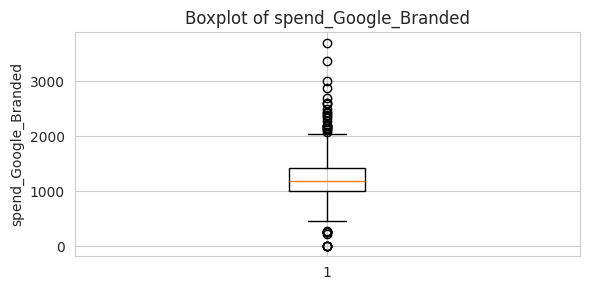

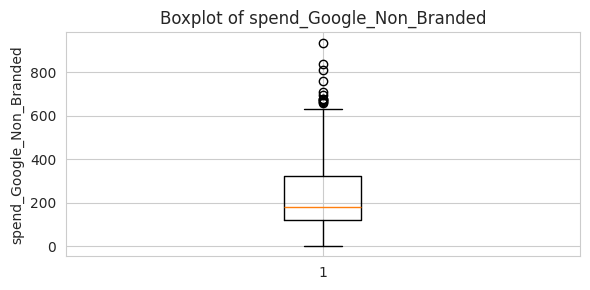

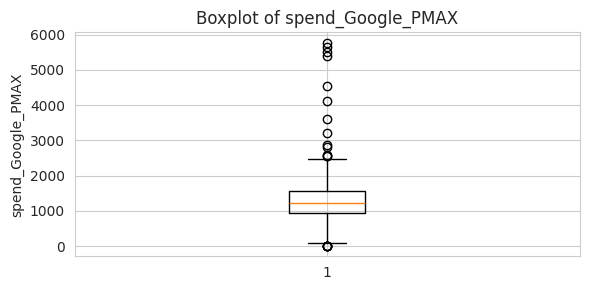

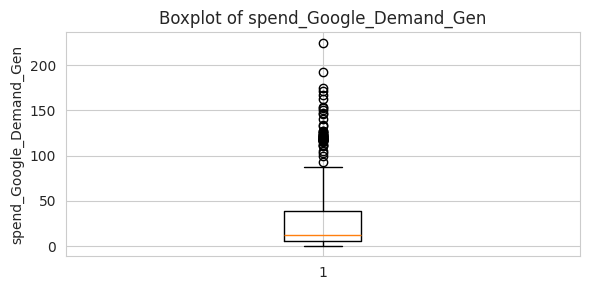

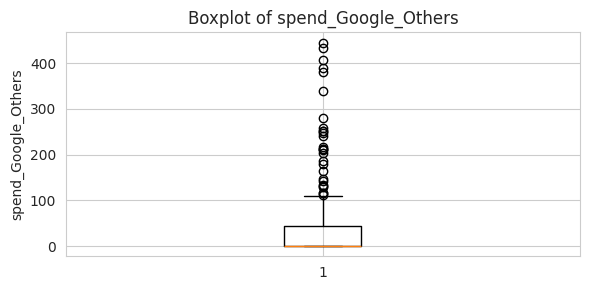

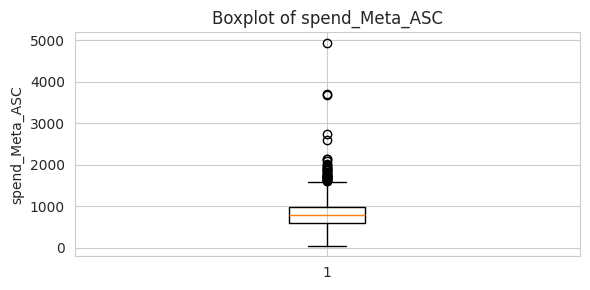

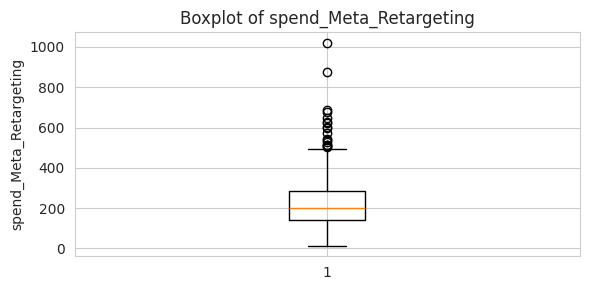

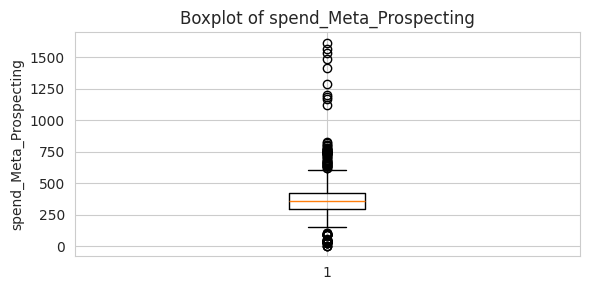

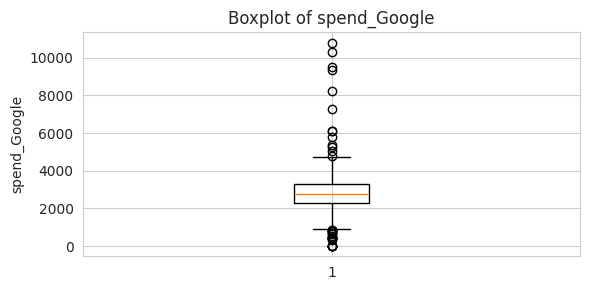

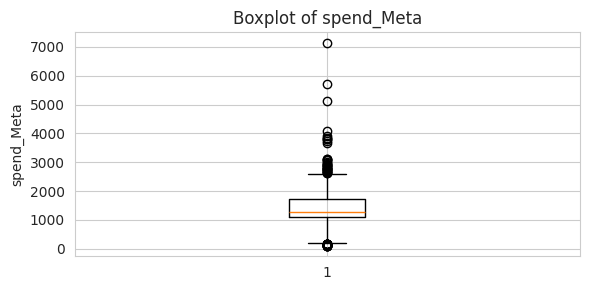

In [9]:
for col in numeric_columns:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col].dropna())
    plt.title("Boxplot of " + col)
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 9. Simple Categorical Graphs



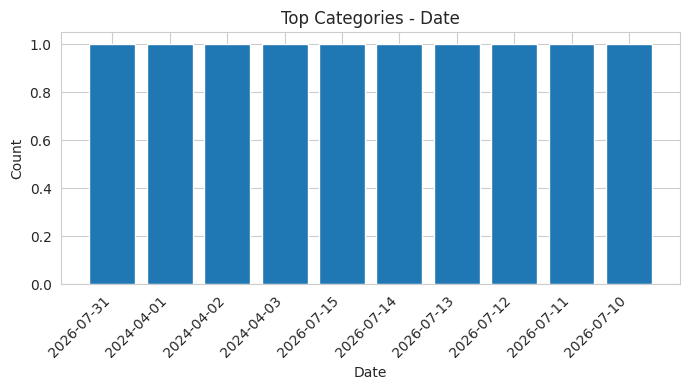

In [10]:
# Simple bar charts for categorical variables
for col in categorical_columns:
    counts = df[col].value_counts().head(10)

    if len(counts) > 0:
        plt.figure(figsize=(7, 4))
        plt.bar(counts.index.astype(str), counts.values)
        plt.title("Top Categories - " + col)
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

## 11. Basic Outlier Check



In [12]:
outlier_results = []

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower_limit) | (df[col] > upper_limit)).sum()

    outlier_results.append([col, outliers])

outlier_table = pd.DataFrame(outlier_results, columns=["Column", "Possible Outliers"])
display(outlier_table)

,Column,Possible Outliers
0,UWG_Mailing,76
1,BFCM_Promo_Effect,17
2,holiday_list,40
3,Offline_Promo,152
4,Promotion_Discount,0
5,Total_Revenue,52
6,Revenue_New_Customer,27
7,influencer_spend,21
8,Awin_spend,49
9,microsoft_spend,15


## 12. Final Dataset Check



In [13]:
print("Final dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

display(df.head())

Final dataset shape: (852, 23)
Total missing values: 0
Total duplicate rows: 0


,Date,UWG_Mailing,BFCM_Promo_Effect,holiday_list,Offline_Promo,Promotion_Discount,Total_Revenue,Revenue_New_Customer,influencer_spend,Awin_spend,microsoft_spend,criteo_spend,cost_outbrain,spend_Google_Branded,spend_Google_Non_Branded,spend_Google_PMAX,spend_Google_Demand_Gen,spend_Google_Others,spend_Meta_ASC,spend_Meta_Retargeting,spend_Meta_Prospecting,spend_Google,spend_Meta
0,2024-04-01,0,0,1,1,1,106943.0,38956.59,0.0,582.67,104.84,235.109051,93.0,1397.096871,248.70,1236.751429,41.532079,56.85,622.880000,289.149999,312.860001,2980.930379,1224.890000
1,2024-04-02,0,0,0,1,1,97629.0,34755.77,0.0,488.37,114.55,213.882456,95.0,1156.952320,239.56,1201.819981,42.691111,37.41,608.129999,281.100000,304.180000,2678.433412,1193.409999
2,2024-04-03,0,0,0,1,1,86273.0,33922.82,0.0,525.69,126.22,149.522513,94.0,1305.355626,245.65,1081.493097,43.278069,34.15,604.330001,278.690000,301.830000,2709.926792,1184.850001
3,2024-04-04,0,0,0,1,1,98247.0,35323.97,0.0,531.80,101.88,145.081980,94.0,1289.010803,300.35,1547.723387,41.585903,27.95,596.169998,276.640000,298.620000,3206.620093,1171.429998
4,2024-04-05,0,0,0,1,1,83678.0,29061.76,0.0,500.02,108.41,128.825199,93.0,1239.129205,344.52,1524.926574,44.156125,23.39,597.270000,277.800001,298.530001,3176.121904,1173.600002
